
# Amazon's seven businesses → a revenue‑by‑segment reel
### A hands‑on **gradient‑sankey** project — built *com todo cuidado e carinho* 💙

Welcome! 👋 Of the "Big Seven" mega‑caps, **Amazon has the most *diversified* revenue** — it isn't
one company, it's **seven stacked on top of each other**: a first‑party retailer, a third‑party
marketplace, a chain of physical stores, an **advertising** platform, a **subscription** empire
(Prime), and the world's biggest cloud, **AWS**. This lesson makes that diversification *visible*:
seven category ribbons flow into one **"Net sales"** hub, sized by **US\$ revenue**, **racing and
re‑ranking year by year** from **FY2019 → the latest fiscal year**.

> 🔭 **A nice narrative aside (the reel itself is about *revenue*):** AWS is only ~15–17% of Amazon's
> *sales*, but it punches far above its weight in **operating profit** — for several years it earned
> the *majority* of Amazon's operating income. So watch AWS's ribbon: it's smaller than the retail
> ribbons, yet it's the **profit engine** of the whole company. (We keep the reel honest — it shows
> revenue — and just flag the profit story here and at the end.)

---

### What we'll build

A **stacked ranking race** with two columns: on the **left**, the **seven product/service
categories**; on the **right**, a single **"Net sales"** hub they all flow into. Ribbon width is
**US\$ billions**, **every frame is one fiscal year**, a footer chart tracks **total net sales**, and
a live **\$ axis** scales itself to the category column. You'll watch **Third‑party seller services**
climb past the slowing first‑party **Online stores** growth, and **Advertising** explode from a
~\$13B footnote to a ~\$56B business.

### Learning outcomes

1. Use the SEC **companyfacts** API the right way (the required **User‑Agent**, disk cache) — and
   discover its **key limitation**: it returns only the *company‑wide total*, **never** the
   axis‑disaggregated (per‑category) members.
2. Make an **honest data decision**: when the API can't give you the breakdown, fall back to the
   **10‑K "Disaggregation of revenue"** footnote — and *cite your sources*.
3. **Reconcile** a hardcoded table against an independent source (the companyfacts total) so you
   *know* it's right, to the dollar.
4. Build a **category → hub** ranking race with `from_dataframe`, the dynamic **\$ axis**
   (`yaxis_node` + `value_prefix="$"` + `yaxis_suffix="B"`), **ranking colours**, and a
   **total‑net‑sales overlay**.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and the pip packages `pandas` and `requests`. The data table, the EDGAR companyfacts fetch and every
> helper are **inlined below as teaching steps**, so you can read the whole ETL pipeline end to end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add
the repo root to `sys.path` so we always get the **local** copy with the newest features.

```bash
pip install gradient-sankey pandas requests   # the public packages
# this notebook uses the LOCAL repo copy of gradient_sankey via sys.path (see below)
```

> ⚠️ **Heads‑up — newest features.** This reel leans on a
> few capabilities that already exist in the **local** `gradient_sankey.py` but may be newer than the
> pinned PyPI release: the **layer‑total value axis** (`yaxis_node` + `yaxis_suffix="B"`),
> `yaxis_gap` / `layer0_label_side`, **ranking colours** (`dynamic_color_mode="ranking"`), and the
> **overlay** controls (`overlay_band`, `overlay_value_suffix`, `overlay_badge`, `overlay_x_labels`).
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We need `pandas` for the data, `requests` for the one EDGAR call, and the library for the visuals.
Rendering an **MP4** also needs **FFmpeg** on your PATH — but the still frames (`save_frame`) need
nothing extra, so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, json, pathlib
from datetime import date

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import pandas as pd
import requests
from requests.adapters import HTTPAdapter
try:
    from urllib3.util.retry import Retry
except ImportError:                          # pragma: no cover
    from requests.packages.urllib3.util.retry import Retry

from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the one EDGAR download, so a re-run is instant.
# Re-fetching from EDGAR on a clean run is fine.
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=1000):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · SEC EDGAR `companyfacts` — and the disaggregation trap 🪤

Every US public company files XBRL‑tagged financials with the SEC. There are two big JSON endpoints:

- **`companyconcept`** — every historical value of *one* concept for *one* company.
- **`companyfacts`** — *all* concepts for one company, in a single (big) JSON.

Both need only a **descriptive `User‑Agent`** (the SEC blocks anonymous clients). Amazon's CIK is
`0001018724`:

```
https://data.sec.gov/api/xbrl/companyfacts/CIK0001018724.json
```

We *want* Amazon's revenue **disaggregated by product/service category** — Online stores, Physical
stores, Third‑party seller services, Advertising, Subscription, AWS, Other. In XBRL those live under
`RevenueFromContractWithCustomerExcludingAssessedTax` **disaggregated by a `ProductOrService` axis**.

> ### ⚠️ The trap
> **`companyfacts` (and `companyconcept`) return only the *default member* of each concept — the
> company‑wide TOTAL — and strip every dimensional / axis‑member fact.** So no matter how you slice
> it, the API gives you **one** revenue number per period (total net sales), with **no per‑category
> breakdown**. We'll *prove* this in a moment, then make an honest decision about what to do.

Let's wire up the same retrying session the repo uses (the public API throttles with HTTP 429).


In [2]:
# A small requests session that retries on SEC throttling (429) and 5xx, carrying the
# REQUIRED SEC User-Agent (set a real SEC_USER_AGENT env var to be a good API citizen).
H = {"User-Agent": os.environ.get(
    "SEC_USER_AGENT", "gradient-sankey-amazon-tutorial/1.0 (contact: you@example.com)")}

def _session():
    s = requests.Session()
    retry = Retry(total=5, backoff_factor=1.0,
                  status_forcelist=(429, 500, 502, 503, 504),
                  allowed_methods=frozenset(["GET"]))
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.headers.update(H)
    return s

SESSION = _session()
AMZN_CIK = "0001018724"
print("User-Agent:", H["User-Agent"])
print("(tip: set a real SEC_USER_AGENT env var to be a good API citizen)")


User-Agent: gradient-sankey-amazon-tutorial/1.0 (contact: you@example.com)
(tip: set a real SEC_USER_AGENT env var to be a good API citizen)



### Download companyfacts (cached) and look at what's actually in there

One download (~4 MB), **disk‑cached** to our local `.nbcache/` so a re‑run is instant.


In [3]:
def load_companyfacts():
    cf = CACHE / f"edgar_companyfacts_CIK{AMZN_CIK}.json"
    if not cf.exists():
        url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{AMZN_CIK}.json"
        print("downloading Amazon companyfacts (~4 MB) ...")
        r = SESSION.get(url, timeout=60); r.raise_for_status()
        cf.write_bytes(r.content)
    return json.loads(cf.read_text(encoding="utf-8"))

facts = load_companyfacts()
gaap = facts["facts"]["us-gaap"]
print("entity:", facts["entityName"])
print("us-gaap concepts available:", len(gaap))

# The total-revenue concept. How many USD facts? And is ANY of them disaggregated?
tag = "RevenueFromContractWithCustomerExcludingAssessedTax"
units = gaap[tag]["units"]["USD"]
keys = set().union(*(u.keys() for u in units))
print(f"\n'{tag}'  ->  {len(units)} USD facts")
print("fact keys present:", sorted(keys))
print("\nNotice: no 'segment'/'member'/'dimension' key — every fact is the company-wide TOTAL.")


downloading Amazon companyfacts (~4 MB) ...


entity: AMAZON COM INC
us-gaap concepts available: 542

'RevenueFromContractWithCustomerExcludingAssessedTax'  ->  124 USD facts
fact keys present: ['accn', 'end', 'filed', 'form', 'fp', 'frame', 'fy', 'start', 'val']

Notice: no 'segment'/'member'/'dimension' key — every fact is the company-wide TOTAL.



**That's the trap, confirmed.** There's no axis/member field — `companyfacts` gives only the default
(total) member. To *see* what we *can* get, let's pull the full‑year totals: a tidy ladder of
Amazon's **total net sales**, and nothing finer.


In [4]:
def days(s, e):
    return (date.fromisoformat(e) - date.fromisoformat(s)).days

# keep the latest-FILED full-year (~365-day) value per period end
best = {}
for u in units:
    if u.get("start") and 350 <= days(u["start"], u["end"]) <= 380:
        e, filed = u["end"], u.get("filed", "")
        if e not in best or filed > best[e][0]:
            best[e] = (filed, u["val"])

edgar_total = {int(e[:4]): val for e, (filed, val) in best.items()}
print("Amazon TOTAL net sales from companyfacts (the only grain it offers):")
for y in sorted(edgar_total):
    print(f"  FY{y}: ${edgar_total[y]/1e9:7.1f}B")


Amazon TOTAL net sales from companyfacts (the only grain it offers):
  FY2016: $  136.0B
  FY2017: $  177.9B
  FY2018: $  232.9B
  FY2019: $  280.5B
  FY2020: $  386.1B
  FY2021: $  469.8B
  FY2022: $  514.0B
  FY2023: $  574.8B
  FY2024: $  638.0B
  FY2025: $  716.9B



## 3 · The honest decision: fall back to the 10‑K footnote 📑

The API can't disaggregate, so we do what a careful analyst does: read the **10‑K**. Amazon publishes
a **"Disaggregation of revenue"** table (in the Segment Information note) breaking net sales into our
seven categories. We transcribe those *reported* figures into a small, **sourced** table — and we'll
**reconcile** it against the companyfacts total so we *know* it's right.

> ### ❓ Why hardcode the segment split (instead of fetching it)?
> Because **there is nothing to fetch**. `companyfacts` returns only the **default member** of each
> XBRL concept and **strips every dimensional / axis member** — so the per‑category facts (tagged on a
> `ProductOrService` axis) simply aren't in the JSON. The only honest source for the split is the
> filing text itself, so we transcribe it **once**, cite it, and **reconcile** it to the dollar against
> the company‑wide total we *can* fetch. Same trade‑off as the Alphabet lesson.

> ### 📅 Why we start at **FY2019**, not 2018
> Amazon only broke out **"Advertising services"** as its own line starting in the **FY2021 10‑K**,
> recasting **2019 and 2020**. It **never recast 2018** — there, advertising stays bundled inside
> **"Other"**. Starting at **2019** gives a clean, **consistent seven‑category series** with no
> apples‑to‑oranges year. (Honesty over one extra frame.)

**Provenance** (each year cited to its 10‑K):
- **FY2022–FY2024** → Amazon **FY2024 10‑K** (filed 2025‑02‑07), `amzn-20241231.htm`
- **FY2019–FY2021** → Amazon **FY2021 10‑K** (filed 2022‑02‑04), `amzn-20211231.htm`
  *(recast: "Advertising services" broken out for 2019 & 2020)*


In [5]:
# Amazon net sales by category, US$ MILLIONS, full fiscal years (= calendar years).
# Source: SEC 10-K "Disaggregation of revenue" tables. Columns:
#   online | physical | 3p_seller | advertising | subscription | aws | other
NET_SALES_BY_CATEGORY = {
    #      online,  physical, 3p_seller, advertising, subscription,    aws,  other
    2019: (141247,   17192,    53762,      12625,        19210,      35026,  1460),
    2020: (197346,   16227,    80461,      19773,        25207,      45370,  1680),
    2021: (222075,   17075,   103366,      31160,        31768,      62202,  2176),
    2022: (220004,   18963,   117716,      37739,        35218,      80096,  4247),
    2023: (231872,   20030,   140053,      46906,        40209,      90757,  4958),
    2024: (247029,   21215,   156146,      56214,        44374,     107556,  5425),
}
COL_ORDER = ["Online stores", "Physical stores", "Third-party seller services",
             "Advertising services", "Subscription services",
             "Amazon Web Services", "Other"]

wide = (pd.DataFrame.from_dict(NET_SALES_BY_CATEGORY, orient="index", columns=COL_ORDER)
        .rename_axis("year"))
print("Amazon net sales by category (US$ millions):")
display(wide)


Amazon net sales by category (US$ millions):


,Online stores,Physical stores,Third-party seller services,Advertising services,Subscription services,Amazon Web Services,Other
year,,,,,,,
2019,141247,17192,53762,12625,19210,35026,1460
2020,197346,16227,80461,19773,25207,45370,1680
2021,222075,17075,103366,31160,31768,62202,2176
2022,220004,18963,117716,37739,35218,80096,4247
2023,231872,20030,140053,46906,40209,90757,4958
2024,247029,21215,156146,56214,44374,107556,5425



### Reconcile — the step that earns your trust 🤝

A hardcoded table is only as good as its **check**. We sum our seven categories per year and compare
to the **independent** companyfacts total we pulled above. They must match **to the dollar** — and we
**assert** it (this is the same guard the flow‑builder below raises on if they ever drift). For
example, FY2023's seven categories sum to **≈ \$574.8B**, exactly Amazon's reported total net sales.


In [6]:
recon = wide.sum(axis=1).to_frame("categories_sum_$M")
recon["edgar_total_$M"] = [edgar_total[y] / 1e6 for y in recon.index]
recon["diff_$M"] = (recon["categories_sum_$M"] - recon["edgar_total_$M"]).round(3)
recon["match"] = recon["diff_$M"].abs() < 1.0
display(recon)
assert recon["match"].all(), "A category row does not reconcile to the EDGAR total!"
print("All years reconcile to the EDGAR companyfacts total, to the dollar. ✓")
print(f"(e.g. FY2023 = ${recon.loc[2023, 'categories_sum_$M']/1000:,.1f}B — Amazon's reported total.)")


,categories_sum_$M,edgar_total_$M,diff_$M,match
year,,,,
2019,280522,280522.0,0.0,True
2020,386064,386064.0,0.0,True
2021,469822,469822.0,0.0,True
2022,513983,513983.0,0.0,True
2023,574785,574785.0,0.0,True
2024,637959,637959.0,0.0,True


All years reconcile to the EDGAR companyfacts total, to the dollar. ✓
(e.g. FY2023 = $574.8B — Amazon's reported total.)



## 4 · Reshape wide → tidy **category → hub** flows

`gradient‑sankey` wants a **tidy long** frame: one row per flow, columns `[year, category, hub,
value]`. Our table is **wide** (one column per category). Like the CO₂ tutorial, the bridge is a
single **`pandas.melt`**. Every category flows into one shared node, **"Net sales"** — so the left
column is the *mix* and the right column is the *whole*.

We convert **US\$ millions → US\$ billions** (`/1e3`) so the axis reads in friendly billions, and we
order the left column by **all‑time total** (biggest category leads), pinning **"Other"** last as the
neutral remainder.


In [7]:
HUB = "Net sales"

long = (wide.reset_index()
        .melt(id_vars="year", value_vars=COL_ORDER,
              var_name="category", value_name="value_m"))
long["value"] = long["value_m"] / 1e3          # US$ millions -> US$ billions
long["hub"] = HUB
long = long[["year", "category", "hub", "value"]]

# left column ordered by all-time total (biggest leads); 'Other' pinned last
cat_order = (long[long.category != "Other"].groupby("category")["value"].sum()
             .sort_values(ascending=False).index.tolist()) + ["Other"]
LAYERS = [cat_order, [HUB]]

print("category order (left, by all-time total):")
for c in cat_order:
    print("   ", c)
print(f"\n{len(long)} tidy [year, category, hub, value] rows, "
      f"{long.year.min()}-{long.year.max()}")
display(long.head(8))


category order (left, by all-time total):
    Online stores
    Third-party seller services
    Amazon Web Services
    Advertising services
    Subscription services
    Physical stores
    Other

42 tidy [year, category, hub, value] rows, 2019-2024


,year,category,hub,value
0,2019,Online stores,Net sales,141.247
1,2020,Online stores,Net sales,197.346
2,2021,Online stores,Net sales,222.075
3,2022,Online stores,Net sales,220.004
4,2023,Online stores,Net sales,231.872
5,2024,Online stores,Net sales,247.029
6,2019,Physical stores,Net sales,17.192
7,2020,Physical stores,Net sales,16.227



### A first read of the story

Before we draw anything, let's confirm the **story** is in the numbers: **Third‑party seller
services** overtaking first‑party **Online stores** *growth*, and **Advertising** going from a
footnote to a juggernaut — the whole reel in a couple of print statements.


In [8]:
piv = wide.copy() / 1e3   # -> $B
print("Online stores vs Third-party seller services (US$ B):")
for y in (2019, 2021, 2024):
    print(f"  FY{y}: online {piv.loc[y,'Online stores']:6.1f}   "
          f"3P seller {piv.loc[y,'Third-party seller services']:6.1f}")

print("\nAdvertising services (US$ B) — from footnote to juggernaut:")
for y in (2019, 2021, 2024):
    print(f"  FY{y}: ${piv.loc[y,'Advertising services']:5.1f}B")

print("\nAWS (US$ B) — small in revenue, but Amazon's profit engine:")
for y in (2019, 2024):
    print(f"  FY{y}: ${piv.loc[y,'Amazon Web Services']:6.1f}B")


Online stores vs Third-party seller services (US$ B):
  FY2019: online  141.2   3P seller   53.8
  FY2021: online  222.1   3P seller  103.4
  FY2024: online  247.0   3P seller  156.1

Advertising services (US$ B) — from footnote to juggernaut:
  FY2019: $ 12.6B
  FY2021: $ 31.2B
  FY2024: $ 56.2B

AWS (US$ B) — small in revenue, but Amazon's profit engine:
  FY2019: $  35.0B
  FY2024: $ 107.6B



## 5 · Fixed colours + the total‑net‑sales overlay

Each category gets a **fixed, meaning‑carrying colour**, and the **hub** is white. The footer chart is
a bar‑chart‑race line of **total net sales**, one point per year — the whole growing under the shifting
mix.


In [9]:
CAT_COLORS = {
    "Online stores":               "#4CC9F0",  # cyan
    "Third-party seller services": "#F72585",  # magenta
    "Amazon Web Services":         "#FF9F1C",  # amber
    "Advertising services":        "#9B5DE5",  # violet
    "Subscription services":       "#52B788",  # green
    "Physical stores":             "#00BBF9",  # blue
    "Other":                       "#6B7280",  # gray
}
node_colors = {c: CAT_COLORS[c] for c in cat_order}
node_colors[HUB] = "#FFFFFF"

years = sorted(long["year"].unique())
total = [float(long[long.year == y]["value"].sum()) for y in years]   # total net sales each year ($B)
xlabels = [str(y) for y in years]
print(f"total net sales: ${total[0]:,.0f}B (FY{years[0]}) -> ${total[-1]:,.0f}B (FY{years[-1]})")


total net sales: $281B (FY2019) -> $638B (FY2024)



## 6 · Building the visual — every knob explained

We hand the tidy `long` + `LAYERS` to `from_dataframe`, then drive the render with the reel's design.
Here's what each knob does in **this** reel:

| Knob | Value | Why |
|---|---|---|
| `ranking_mode` | `True` | reorder categories by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with US\$ (biggest = tallest) |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `dynamic_color_mode` / `dynamic_colormap` | `"ranking"` / `"plasma"` ⚠️ | recolour categories by **live rank** each frame |
| `link_glow` / `link_alpha` | `1` / `0.55` | soft neon glow behind the ribbons |
| `n_segments` | `100` | smooth gradients along each ribbon |
| `yaxis_node` | `cat_order[0]` ⚠️ | draw a value axis scaled to the **category‑layer total** |
| `yaxis_suffix` / `value_prefix` | `"B"` / `"$"` ⚠️ | ticks read like `$300B` — **dollars** |
| `yaxis_gap` / `layer0_label_side` | `0.15` / `"left"` ⚠️ | axis hugs the category column; names on the left |
| `overlay_series` / `overlay_x_labels` | total / years | the footer race chart |
| `overlay_band` | `(0.18, 0.56)` ⚠️ | push the line chart **lower**, clear of the Sankey |

First, build the renderer — the single call that ingests everything.


In [10]:
sk = Sankey.from_dataframe(
    df=long, layers=LAYERS,
    time_col="year", source_col="category", target_col="hub", value_col="value",
    node_colors=node_colors,
)
anchor = cat_order[0]    # the biggest category identifies the left layer for the $ axis
print(f"{len(sk.frames)} frames (years):",
      sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("$ axis anchored on the category layer of:", anchor)


6 frames (years): 2019 -> 2024
$ axis anchored on the category layer of: Online stores



## 7 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render the two years that
bookend the story:

- **FY2019** — Online stores towers; Advertising is a sliver,
- **FY2024** — Third‑party + Advertising have swelled, the whole thing far bigger.

The **\$ axis** (`yaxis_node` + `value_prefix="$"`) and `layer0_label_side` all work in stills.
(Ranking *colours* are animation‑only, so the stills show each category in its **fixed** colour — the
clip below adds the live rank colouring.)


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\amazon_2019.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\amazon_2019.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\amazon_2024.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\amazon_2024.png


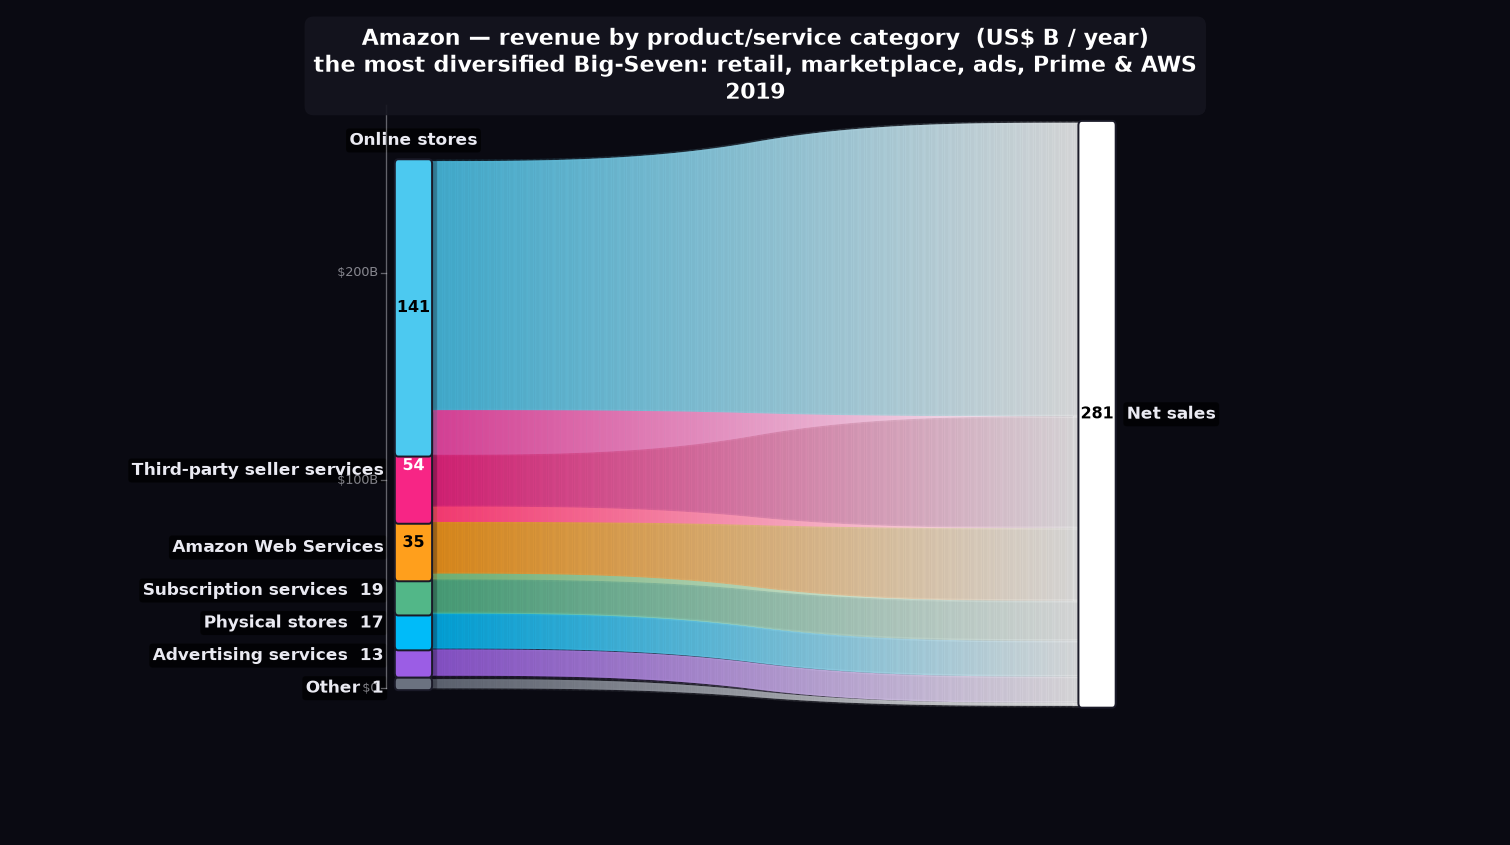

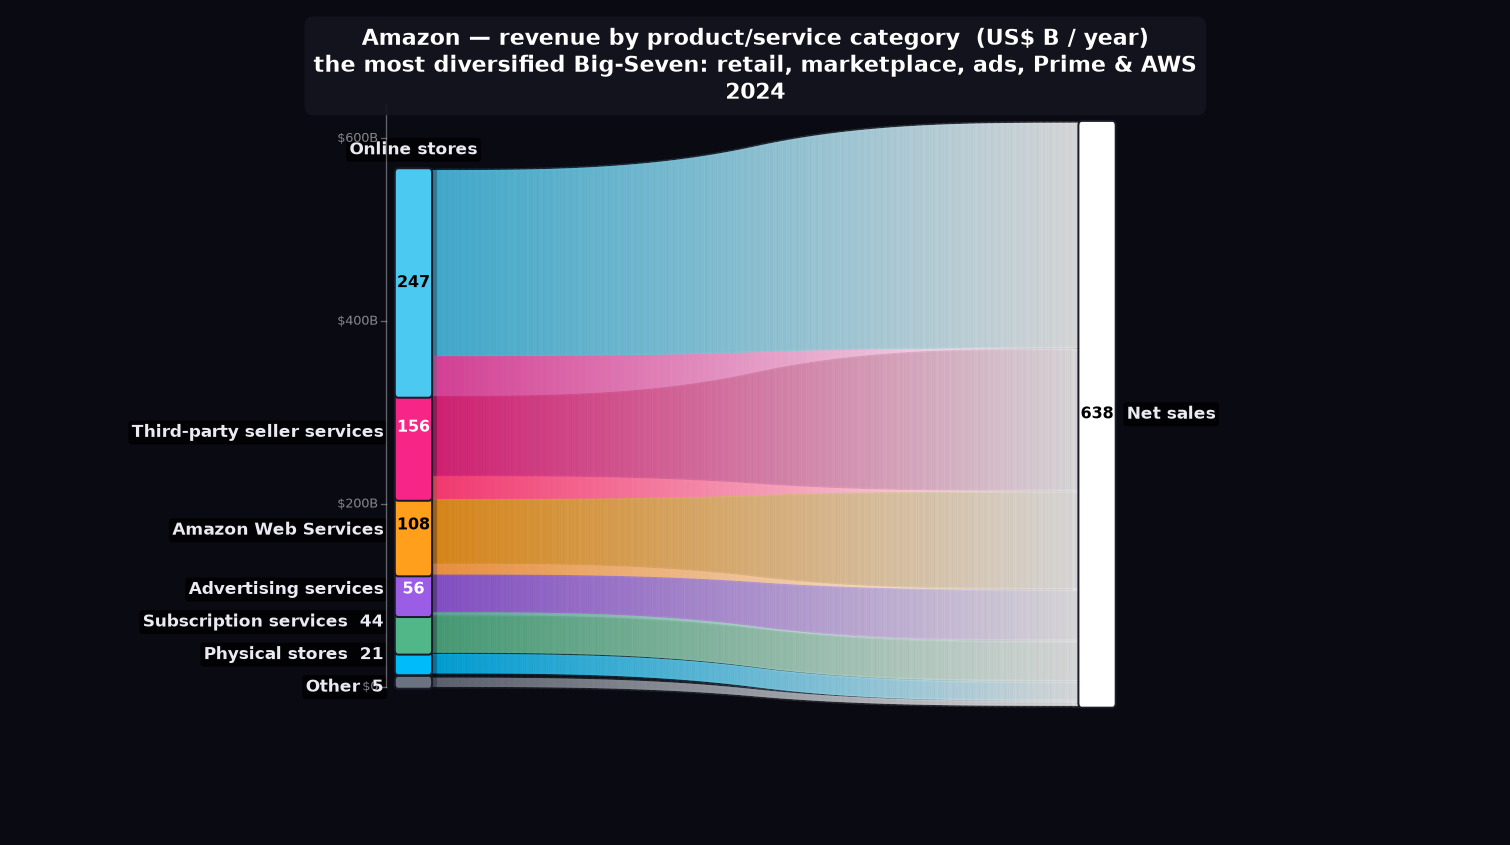

In [11]:
# NOTE: ranking colours (dynamic_color_mode) are ANIMATION-only — save_frame() uses
# the fixed node_colors. The stills therefore show each category in its fixed colour;
# the clip below adds the live rank colouring. Everything else matches the reel.
still_design = dict(
    figsize=(16, 9), dpi=95, font_size=13, title_fontsize=17, padding=2.8,
    margin_top=0.17, margin_bottom=0.22,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
    yaxis_node=anchor, yaxis_suffix="B",             # $ axis, scaled to the category-layer TOTAL
    yaxis_gap=0.15, layer0_label_side="left",        # axis hugs the categories; names on the left
    value_prefix="$",
)
TITLE = ("Amazon — revenue by product/service category  (US$ B / year)\n"
         "the most diversified Big-Seven: retail, marketplace, ads, Prime & AWS")

year_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for yr in ("2019", "2024"):
    if yr not in year_to_index:
        continue
    p = os.path.join(ASSETS, f"amazon_{yr}.png")
    sk.save_frame(p, frame_index=year_to_index[yr], title=TITLE, **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation 🎬

A tiny clip to prove the motion, with the **full** reel design: dark theme, ranking colours, glow, the
\$ axis, and the total‑net‑sales overlay. We keep it short for speed. The cell **skips gracefully** if
FFmpeg isn't installed — but if it is, you'll see the categories re‑rank in real time.


In [12]:
sample_mp4 = os.path.join(ASSETS, "amazon_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=8, quality="medium", n_workers=2,
        title=TITLE,
        font_size=13, title_fontsize=17, padding=2.8,
        margin_top=0.17, margin_bottom=0.22,
        ranking_mode=True, stacked_mode=True,
        theme="dark", link_glow=1, link_alpha=0.55, n_segments=100,
        dynamic_color_mode="ranking", dynamic_colormap="plasma",
        yaxis_node=anchor, yaxis_suffix="B", yaxis_gap=0.15, layer0_label_side="left",
        value_prefix="$",
        overlay_series=total, overlay_x_labels=xlabels,
        overlay_label="Total net sales  (US$ B / year)",
        overlay_color="#7CFF6B", overlay_value_suffix="B", overlay_badge="AMZN",
        overlay_band=(0.18, 0.56),                                    # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 2
  - Nodes per layer: [7, 1]
  - FPS: 24, Duration: 8s
  - Quality: medium
  - Total frames: 192
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Ranking
  - Colormap: plasma

Pre-computing 192 frames...
  Pre-computation: 0.07s
  Workers: 2

Rendering on 2 parallel processes...


Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.
Reason: RuntimeError('chunk 1 failed after 3 attempts: [WinError 1455] The paging file is too small for this operation to complete')



### The full reel — wrap it in one function

Everything above is the whole pipeline. To make it a one‑liner you'd wrap the steps you ran into a
single function — extract (companyfacts total) → reconcile the 10‑K table → `melt` → `from_dataframe`
→ `animate` — and parameterise the window (`y0`, `y1`), the colormap and the duration. Sketch:

```python
def amazon_reel(out, *, y0=2019, y1=None, duration=40.0, cmap="plasma"):
    # (1) reconcile + melt -> tidy long  (the §3-§4 cells above, parameterised by y0/y1)
    # (2) sk = Sankey.from_dataframe(long, [cat_order, [HUB]], ...)
    # (3) sk.animate(out, duration_seconds=duration, ranking_mode=True, stacked_mode=True,
    #                theme="dark", dynamic_color_mode="ranking", dynamic_colormap=cmap,
    #                yaxis_node=cat_order[0], yaxis_suffix="B", value_prefix="$",
    #                overlay_series=total, overlay_x_labels=xlabels, overlay_badge="AMZN")
    ...
```

> 🗂️ **A nice habit:** stamp every rendered filename with a **big‑endian, sortable** date‑time prefix
> (`%Y-%m-%d-%Hh%M`, with `:` → `h` because it's illegal in paths) — e.g. `2026-06-13-16h21_amazon.mp4`
> — so your renders always sort chronologically.



## 8 · Recap & try it yourself

🎉 **You built the whole reel** — and, just as importantly, you made an **honest data decision** along
the way. The SEC `companyfacts` API couldn't give the per‑category breakdown (it only ever returns the
company‑wide total), so we fell back to the **10‑K disaggregation footnote**, *cited every year to its
filing*, and **reconciled** the hardcoded table against the companyfacts total to the dollar.

**The pipeline, in one breath:** pull Amazon's **total** net sales from EDGAR companyfacts (cached) →
discover it can't disaggregate → transcribe the **10‑K category table** (FY2019→latest, consistent
seven‑category series) → **reconcile** to the EDGAR total → **`melt`** into tidy `[year, category,
hub, value]` → fixed **category colours** + **total‑net‑sales** overlay → `from_dataframe` →
`save_frame` stills + `animate` with the dark theme, **ranking colours**, the **\$ axis** and
`overlay_band`.

> 💙 **The honest framing.** This reel is about **revenue**. AWS is a modest slice of *sales* but the
> lion's share of *operating profit* — a great thing to say out loud over the reel, but we never let
> the *picture* imply AWS is the biggest *revenue* line, because it isn't.

### 🧪 Try it yourself

1. **A profit reel.** Amazon reports **operating income by reportable segment** (North America,
   International, AWS) in the same note — build a *profit* ranking race and watch AWS dominate.
2. **Reportable segments.** Swap the seven product/service categories for the **three reportable
   segments** (North America / International / AWS) for a coarser, also‑honest view.
3. **Another colormap.** Pass `dynamic_colormap="turbo"` (or `"viridis"`) to recolour the rank race.
4. **Another filer.** Point `load_companyfacts` at a different CIK (Microsoft `0000789019`, Apple
   `0000320193`) to pull *its* total — then find *its* 10‑K disaggregation table.
5. **Share of total.** Normalise each category by the year's total to animate **revenue *mix* %**
   instead of absolute dollars.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- SEC EDGAR companyfacts: https://data.sec.gov/api/xbrl/companyfacts/CIK0001018724.json (needs a User‑Agent)
- Amazon 10‑K filings: https://www.sec.gov/cgi-bin/browse-edgar?action=getcompany&CIK=0001018724&type=10-K
- Companion tutorials: `notebooks/01_tutorial_nvidia_income.ipynb` (same SEC world),
  `notebooks/11_tutorial_alphabet.ipynb` (same SEC P&L + hardcoded 10‑K segment table)

*Built com todo cuidado e carinho. Data: SEC EDGAR (companyfacts total) + Amazon 10‑K disaggregation
footnotes, reconciled to the dollar. Happy hacking!*
